#  Transaction Analysis for Market Expansion


In [1]:
import pandas as pd
import pyodbc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-55JNORK\\SQLEXPRESS;"
    "Database=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;")
cursor = conn.cursor()
print(" successfully")

 successfully


## Scenario

PhonePe wants to understand transaction performance across
different states and identify important regions for market
expansion.

This analysis focuses on transaction volume and value across
states.
## Objective

- Identify top-performing states.
- Compare transaction amounts across states.
- Understand transaction distribution.
- Identify potential markets for expansion.

### load data

In [3]:
query4 = """
select top 10 *
from aggregated_transaction"""

df4= pd.read_sql(query4, conn)
df4

C:\Users\Devendra\AppData\Local\Temp\ipykernel_3584\2090758528.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4= pd.read_sql(query4, conn)


,States,Years,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,Assam,2023,1,Financial Services,82270,86978703
1,Assam,2023,1,Others,116656,74768264
2,Assam,2023,2,Merchant payments,62403711,45515248236
3,Assam,2023,2,Peer-to-peer payments,57852989,182809282981
4,Assam,2023,2,Recharge & bill payments,17858409,6631355080
5,Assam,2023,2,Financial Services,81172,84797972
6,Assam,2023,2,Others,94672,70104514
7,Assam,2023,3,Merchant payments,82126315,51533166362
8,Assam,2023,3,Peer-to-peer payments,66737077,185030502675
9,Assam,2023,3,Recharge & bill payments,18524152,7310558505


## top states

C:\Users\Devendra\AppData\Local\Temp\ipykernel_3584\2467002950.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trans = pd.read_sql(query, conn)


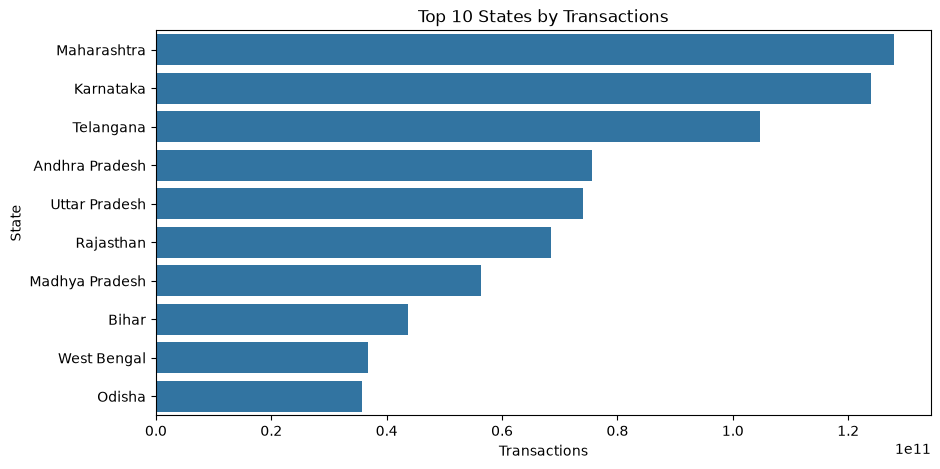

In [4]:
query = """
SELECT TOP 10
    States,
    SUM(Transaction_count) AS Total_Transactions
FROM aggregated_transaction
GROUP BY States
ORDER BY Total_Transactions DESC
"""

df_trans = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_trans, x="Total_Transactions", y="States")

plt.title("Top 10 States by Transactions")
plt.xlabel("Transactions")
plt.ylabel("State")
plt.show()

### “This chart shows which states have the highest number of PhonePe transactions.”

#### Transaction Amount by State

C:\Users\Devendra\AppData\Local\Temp\ipykernel_3584\4178113714.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_amount = pd.read_sql(query, conn)


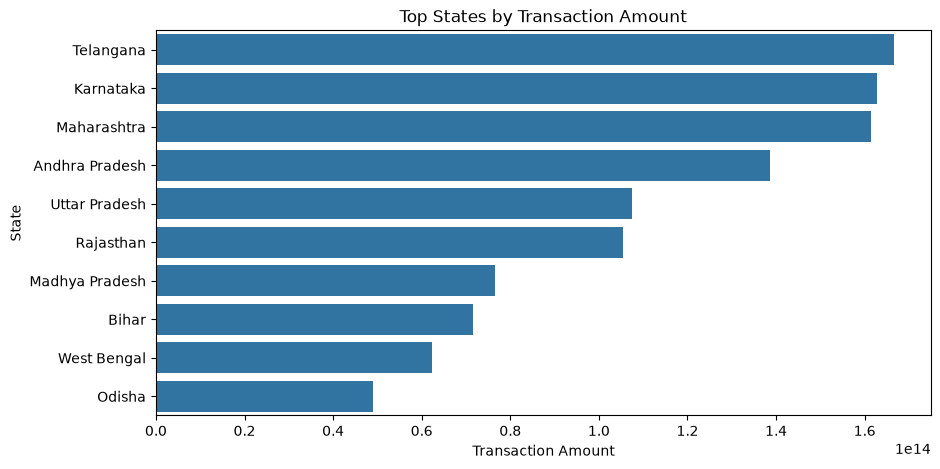

In [5]:
query = """
SELECT TOP 10
    States,
    SUM(Transaction_amount) AS Total_Amount
FROM aggregated_transaction
GROUP BY States
ORDER BY Total_Amount DESC
"""

df_amount = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=df_amount, x="Total_Amount", y="States")

plt.title("Top States by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("State")
plt.show()

### “This chart shows the states where the total transaction value is highest.”

### Transaction Growth by Year

C:\Users\Devendra\AppData\Local\Temp\ipykernel_3584\2581634224.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_year = pd.read_sql(query, conn)


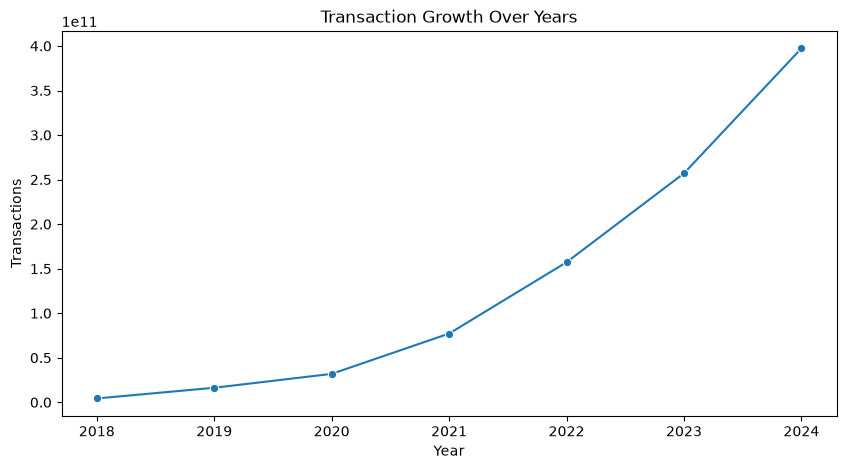

In [6]:
query = """
SELECT
    Years,
    SUM(Transaction_count) AS Total_Transactions
FROM aggregated_transaction
GROUP BY Years
ORDER BY Years
"""

df_year = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.lineplot(data=df_year, x="Years", y="Total_Transactions", marker="o")

plt.title("Transaction Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Transactions")
plt.show()

#### This line chart shows how PhonePe transaction volume has changed over the years.”

### Recommendations
Focus on high-transaction states → Increase marketing and partnerships.

Target high-value states → Promote premium services.

Expand growing regions → Invest in high-growth markets.

Improve low-performing states → Use offers and cashback.

## Conclusion

The analysis identifies top-performing states and transaction trends. These insights help PhonePe understand strong markets, improve payment services, and plan future market expansion.